# Minimization

- Incredibly broad topic, particularly important nowadays with the rise of machine learning.

- This lesson will not explain any useful minimization algorithms, as it will be more like an introduction game.

- Let's start with a funny example: the random walk.

    - The random walk has its firm place in the history of physics, as the Brownian motion is a random walk of a particle in a fluid.

# Random walk in 2D

- See the following code. Note:

    - Choice of the direction is simple in 2D: we just generate a random number between 0 and $2\pi$, and calculate cosine and sine of this angle to get the "unit" step.

    - The code stops when the walker reaches the boundary of the box.

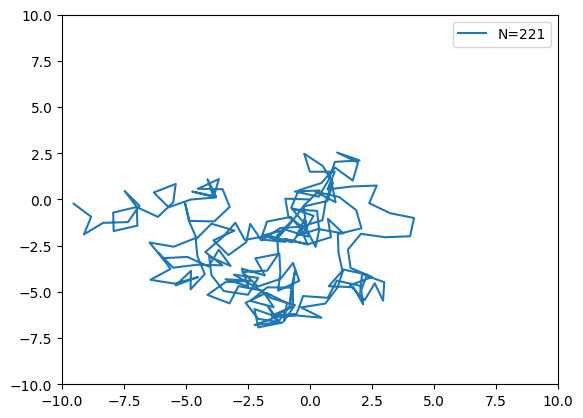

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def random_direction_2d():
    """ Generates a random direction in the 2D plane """
    phi = np.random.uniform(0, 2 * np.pi)
    return np.array([np.cos(phi), np.sin(phi)])
    

def random_walk(direction_generator, dimension = 2, initial_condition = [0, 0], num_steps = 1000, step_size = 1, box_size = 10, cyclic = True):
    """
    Generates and plots a random walk in a n-D space.

    If the trajectory leaves the given box, the calculation is interrupted.
    The default parameters are set for a 2D random walk.
    To use the function for a different dimension, set the `dimension` parameter and `initial_condition` accordingly.
    The `direction_generator` should be a function that generates a unitary vector
    representing a random direction in the given dimension.
    """    
    position = np.array(initial_condition)
    path = [position]

    box = np.array([box_size] * dimension)

    for _ in range(0, num_steps):
        position = position + step_size * direction_generator()

        # A check whether we leave the given box.
        if (position < -box).any() or (position > box).any():
            if cyclic:
                position = np.mod(position + box, 2 * box) - box
            else:
                break

        path.append(position)

    return np.array(path)

def plot_random_walk_2d(path, box_size = 10):

    plt.plot(path[:,0], path[:,1], label=f"N={len(path)}")
    plt.xlim(-box_size, box_size)
    plt.ylim(-box_size, box_size)
    plt.legend()
    plt.show()

plot_random_walk_2d(random_walk(random_direction_2d, cyclic = False))

- The script /home/teaching/NOFY084/plesv6am/12_random_walk_2d_interactive.py displays the random walk in real time. The cyclic boundary conditions is set to `True` by default.

    - Download the script and run it on your computer.

# Random walk in 3D

- In 3D, we cannot generate two spherical angles, as we would get a non-uniform distribution of the directions.

- Instead, we can generate:

    - The angle $\phi$ from a uniform distribution between 0 and $2\pi$.

    - The cosine of the angle $\theta$ from a uniform distribution between -1 and 1.

    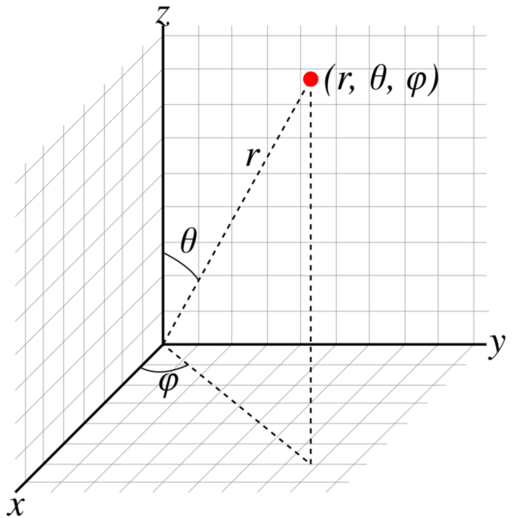

- Calling the two random numbers $\xi_1$ and $\xi_2$, the angles $\phi$ and $\theta$ are then given by:

    \begin{align}
        \phi&=\xi_{1},\nonumber\\
        \theta&=\arccos\left(\xi_{2}\right),
    \end{align}

    and the unit vector in the direction is:

    \begin{align}
        \mathbf{e} = (\sin\theta \cos\phi, \sin\theta \sin\phi, \cos\theta)
    \end{align}

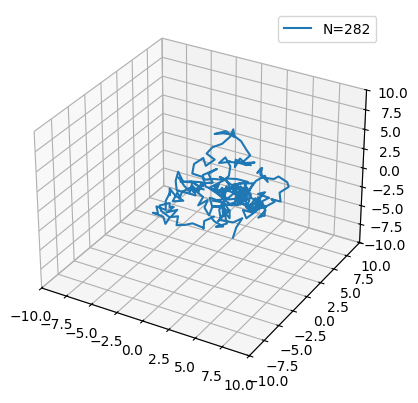

In [48]:
# Generate and plot a random walk in 3D.

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def random_direction_3d():
    """ Generates a random direction in the 3D space """
    phi   = np.random.uniform(0, 2 * np.pi)
    theta = np.arccos(np.random.uniform(-1, 1))

    # Return the unitary vector in the direction given by the angles phi and theta.
    return np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)])

def plot_random_walk_3d(path, box_size = 10):
    """ Plots the given path in 3D. """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(path[:,0], path[:,1], path[:,2], label=f"N={len(path)}")
    ax.set_xlim(-box_size, box_size)
    ax.set_ylim(-box_size, box_size)
    ax.set_zlim(-box_size, box_size)
    ax.legend()
    plt.show()

plot_random_walk_3d(random_walk(random_direction_3d, dimension = 3, initial_condition = [0, 0, 0], cyclic = False))

# Random walk in n-D

- The random direction generation using goniometric functions becomes more and more complicated as the dimension increases.

- Instead, we can profit from the fact that the normal distribution with the covariance matrix equal to the identity matrix is isotropic in n-D. Cookbook recipe:

    - Generate n random numbers from a normal distribution with $\mu = 0$ and $\sigma = 1$.
    
    - Use the numbers as components of an n-D vector.
    
    - Divide the vector by its norm.

In [52]:
# Function generating a random direction in n-D space.
def random_direction_gaussian(dimension):
    """
    Generates a random direction in the n-D space.

    References:
    [1] M.E. Muller, A note on a method for generating points uniformly on n-dimensional spheres,
            Communications of the Asociation for Computing Machinery 2, 19 (1959)
    [2] G. Marsaglia, Choosing a Point from the Surface of a Sphere,
            The Annals of Mathematical Statistics 43, 645 (1972)

    Parameters:
    -----------
    dimension : int
        The dimension of the space in which the random direction is generated.
        Any positive integer is allowed.

    Returns:
    --------
    direction : np.ndarray
        A unitary vector representing a random direction in the n-D space.
    """

    # Generate a random vector with normally distributed components.
    random_vector = np.random.normal(size=dimension)

    # Normalize the vector to get a unitary vector.
    norm = np.linalg.norm(random_vector)
    if norm == 0:
        return random_direction(dimension)  # Regenerate if we get a zero vector.
    
    # Return the unitary vector.
    return random_vector / norm

# Minimization

- The random walk is a very inefficient way to find the minimum of a function, but it is a good starting point to understand the concept of minimization.

- Cookbook recipe:

    1. Start from a random point in the space.

    2. Choose a step size.

    3. Generate a random direction.

    4. If the function value at the new point is lower than the previous one, move to it.

    5. Go to step 2 and repeat until some stopping criterion is met.

- The stopping criterion can be:

    - A move was rejected a certain number of times in a row.

    - The function value was not improved a certain number of times in a row. Here, a relative tolerance should be set to define what "not improved" means.

    - The step size reaches some threshold value.

    - Come up with your own criterion.

- The code below minimizes a function using the random walk algorithm. The step size can be constant or adaptive.

    - For the adaptive step size, the code reduces the step size by a factor of 2 every time it fails to find a better position for `max_failed_steps` consecutive steps.
    
    - For the non-adaptive step size, the step size remains constant throughout the optimization. The stopping criterion is set to `max_failed_steps = 100` rejected moves in a row.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
   
def random_walk_minimizer(function, dimension = 2, initial_step_size = 0.1, final_step_size = 1e-6, initial_condition = None, initial_condition_box = 1, max_failed_steps = 100, adaptive_step_size = True):
    """
    Simple minimization method using random walk.

    Parameters:
    -----------
    function : callable
        The function to minimize.
    dimension : int, optional
        The dimensionality of the function. Default is 2.
    initial_step_size : float, optional
        The initial step size for the random walk. Default is 0.1.
    final_step_size : float, optional
        The final step size for the random walk. Default is 1e-6.
    initial_condition : array-like, optional
        The starting point; if None, initial conditions chosen randomly from a box of size given by initial_condition_box.
    initial_condition_box : float, optional
        The size of the box from which to choose the initial condition. Default is 1.
    max_failed_steps : int, optional
        The number of steps to stop the calculation. Default is 100.
    adaptive_step_size : bool, optional
        Whether to adapt the step size during the optimization.
        If True, the step size is reduced by a factor of 2 every time we fail
        to find a better position for `max_failed_steps` consecutive steps.
        If False, the step size remains constant throughout the optimization,
        and the stopping criterion is simply `failed_steps == max_failed_steps`.
    """

    # Set the starting position.
    if initial_condition is None:
        initial_condition = np.random.uniform(-initial_condition_box, initial_condition_box, size = dimension)
    position = np.array(initial_condition)
    f = function(position)
    path = [position]

    # Number of consecutive steps in which we haven't moved.
    failed_steps = 0

    # Initial step size.
    step_size = initial_step_size

    # Total number of steps.
    num_steps = 0

    # The random walk.
    while ((adaptive_step_size) and (step_size > final_step_size)) or ((not adaptive_step_size) and (failed_steps < max_failed_steps)):
        new_position = position + step_size * random_direction_gaussian(dimension)
        newf = function(new_position)

        if newf < f:
            position = new_position
            f = newf

            path.append(position)

            failed_steps = 0

        else:
            failed_steps += 1           # Rejected step

            if adaptive_step_size and failed_steps > max_failed_steps:
                failed_steps = 0
                step_size *= 0.5        # Step size reduced by half 

        num_steps += 1

    print(f"Minimum = {position}, function value = {f}, steps = {num_steps}")

    return np.array(path)


- Minimize the function $f(x, y) = x^2 + y^2$

In [71]:
# Define the function to minimize.
def f(x):
    return x[0]**2 + x[1]**2

# Run the minimization.
# Check the number of steps and the minimum found by the algorithm.
# You can see that the non-adaptive step size takes less steps,
# but it doesn't find the minimum as accurately as the adaptive step size.
_ = random_walk_minimizer(f, adaptive_step_size = True)

Minimum = [2.87992473e-07 1.27240439e-07], function value = 9.912979408749197e-14, steps = 1875


- Let's plot the path taken by the algorithm on the contour plot of the function. You can see that the non-adaptive step size takes less steps, but it doesn't find the minimum as accurately as the adaptive step size.

In [72]:
# Colour maps for the contour graph
from matplotlib import cm

def show_graph(function, paths = (), box_size = 1, num_contours = 100):
    """
    Plots a contour graphs of the give 2D function.

    Parameters:
    -----------
    function : callable
        The function to plot.
    paths : tuple, optional
        The paths to plot in the graph.
        There can be any number of paths plotted in the same graph.
    box_size : float, optional
        The limits of the x, y range.
    num_contours : int, optional
        The number of contours in the graph.
    """

    # Range of x and y values for the graph.
    x = y = np.linspace(-box_size, box_size, 100)

    # Grid for calculating values of the function on the graph.
    grid_x, grid_y = np.meshgrid(x, y)
    grid_z = function([grid_x, grid_y])

    plt.figure(figsize=(8,6))
    plt.contourf(grid_x, grid_y, grid_z, num_contours, cmap = cm.hot)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(label = function.__name__ + '(x,y)')

    for path in paths:
        plt.plot(path[:,0], path[:,1])  
        plt.scatter(path[[0,-1],0], path[[0,-1],1])  # Indicate the initial and final points of the path
    plt.tight_layout()
    plt.show()


Minimum = [4.71417991e-07 2.16981684e-07], function value = 2.6931597329182256e-13, steps = 1967


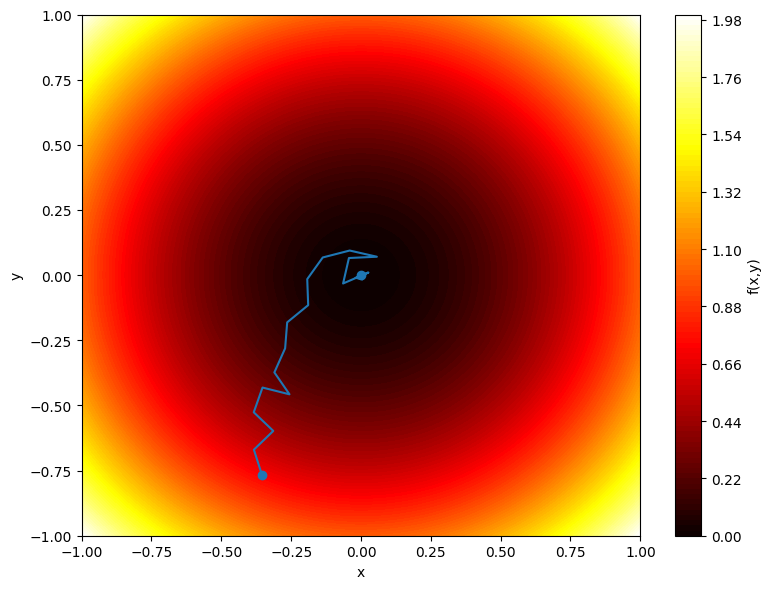

In [81]:
path = random_walk_minimizer(f, adaptive_step_size = True, initial_condition_box = 2)
show_graph(f, paths = (path,))

- Find the minimum of the Rosenbrock function:

    \begin{align}
        f(x, y) = (a - x)^2 + b(y - x^2)^2
    \end{align}

    where $a = 1$ and $b = 100$.

Minimum = [0.99999936 0.99999872], function value = 4.0673704560156944e-13, steps = 3196
Minimum = [0.99999696 0.99999401], function value = 1.0175443611750326e-11, steps = 3188
Minimum = [1.00000048 1.00000083], function value = 1.691254352705349e-12, steps = 3306
Minimum = [0.99999934 0.99999867], function value = 4.410936550363753e-13, steps = 2474
Minimum = [0.99999899 0.99999794], function value = 1.2497730555631733e-12, steps = 2963


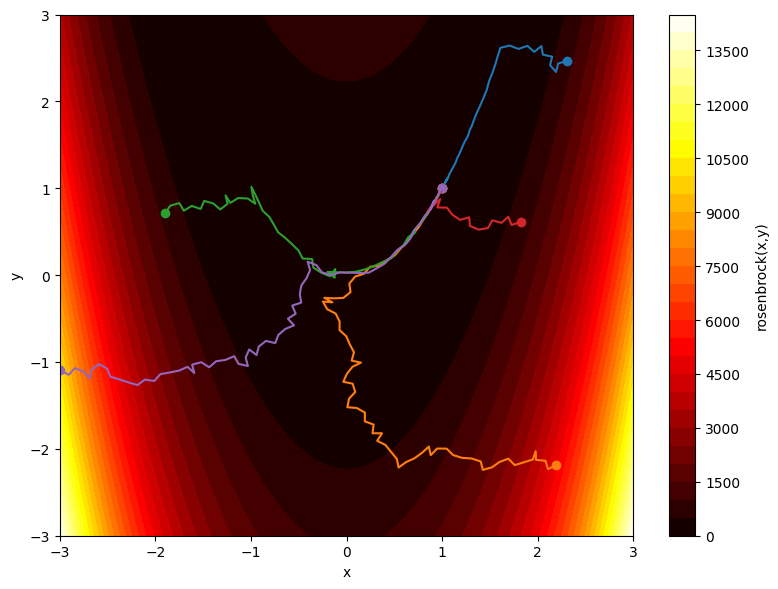

In [122]:
def rosenbrock(point, parameters = (1, 100)):
    """
    Rosenbrock test function: https://en.wikipedia.org/wiki/Rosenbrock_function
    """
    x, y = point
    a, b = parameters

    return (a - x)**2 + b * (y - x * x)**2

paths = []
for _ in range(5):
    path = random_walk_minimizer(rosenbrock, adaptive_step_size = True, initial_condition_box = 3)
    paths.append(path)
show_graph(rosenbrock, paths = paths, box_size = 3, num_contours = 30)